Loaded C. elegans connectome: 279 neurons, 3225 directed synaptic connections
Mean node strength c = 24.44 | 3D Physical range: [0.5 - 776.6] um | r0 = 8.47 um
C. ELEGANS CONNECTOME INFERENCE COMPLETE (Runtime: 2.30s)
• Inferred Lambda (Social/Functional weight) : 0.9787 +/- 0.0200
• 95% Confidence Interval                   : [0.9395, 1.0000]
• Inferred Spatial Interaction Scale (r)    : 170.05 um
• Functional / Non-local Synaptic Fraction  : 97.9%
• Purely Spatial Physical Fraction          : 2.1%


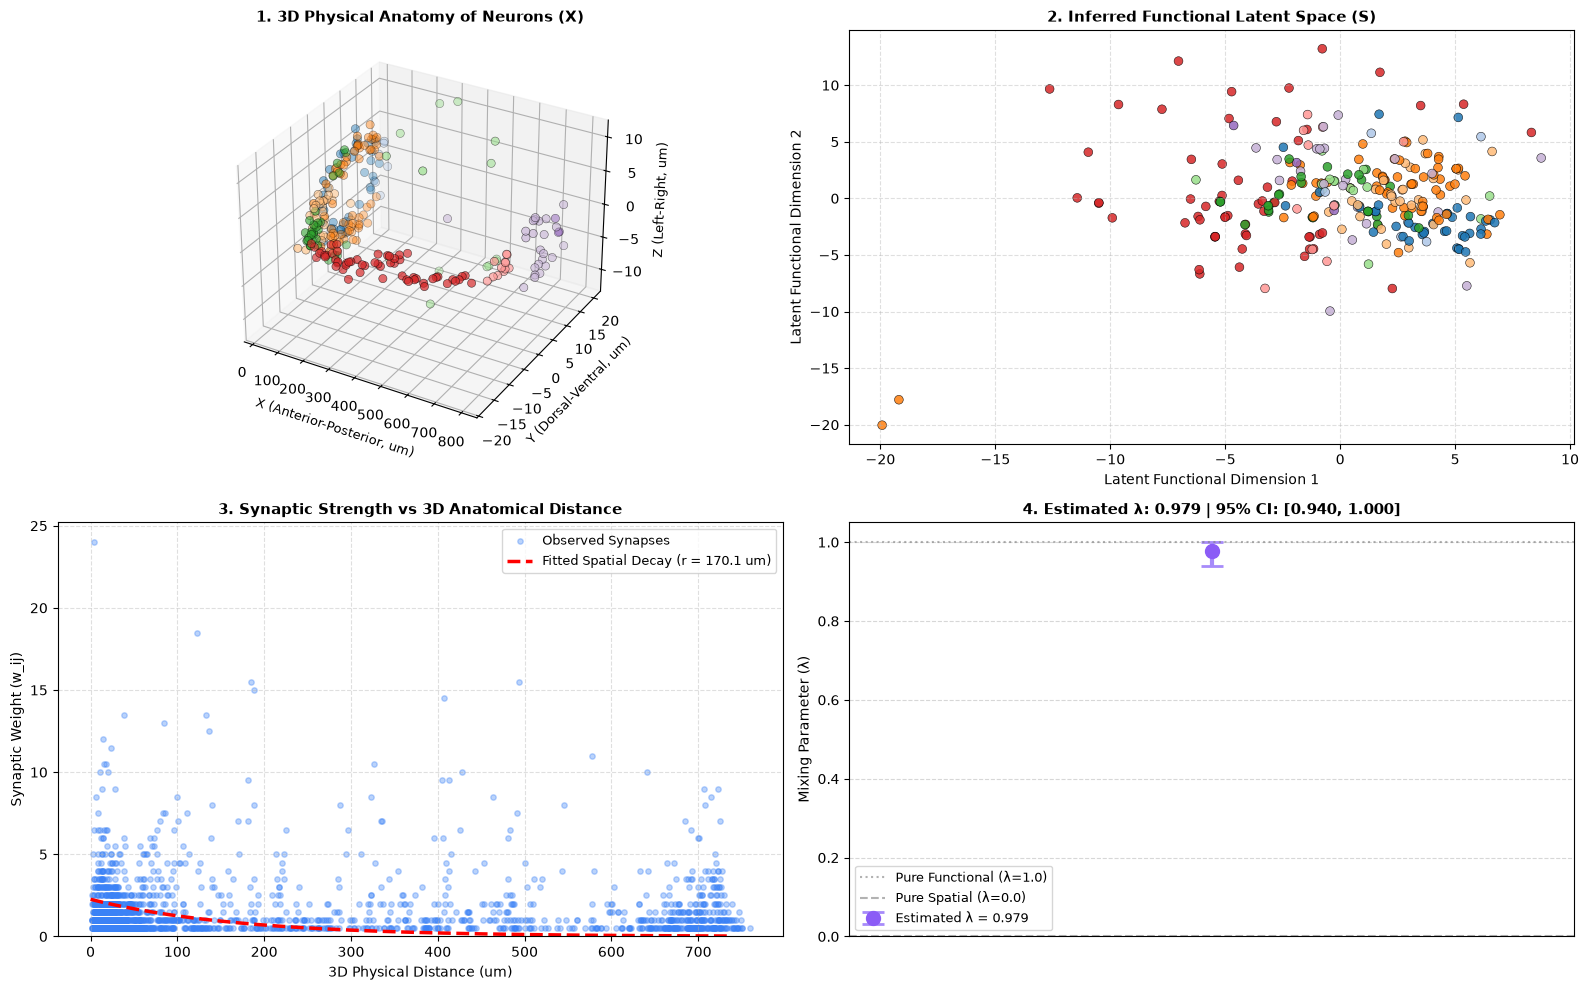

In [6]:
# ======================================================================
# C. ELEGANS CONNECTOME: INFERENCE OF PHYSICAL VS FUNCTIONAL/SOCIAL DUALITY
# ======================================================================

import time
import torch
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

device = torch.device("cpu")
torch.manual_seed(0)
np.random.seed(0)

# ----------------------------------------------------------------------
# 1. Load C. elegans Connectome & 3D Coordinates
# ----------------------------------------------------------------------
graph_path = "data/c_elegans/celegans_connectome.graphml"
coords_path = "data/c_elegans/3D_coordinates_celegans.csv"

# Load GraphML
G = nx.read_graphml(graph_path)
nodes = list(G.nodes())
N = len(nodes)
node_to_idx = {n: i for i, n in enumerate(nodes)}

print(f"Loaded C. elegans connectome: {N} neurons, {G.number_of_edges()} directed synaptic connections")

# Extract neuron metadata & 3D coordinates (x, y, z)
cell_names = [G.nodes[n].get("cell_name", n) for n in nodes]
cell_classes = [G.nodes[n].get("cell_class", "Unknown") for n in nodes]
ganglia = [G.nodes[n].get("ganglia", "Unknown") for n in nodes]

coords = []
for n in nodes:
    x = float(G.nodes[n]["x"])
    y = float(G.nodes[n]["y"])
    z = float(G.nodes[n]["z"])
    coords.append([x, y, z])
X_3d = np.array(coords)

# ----------------------------------------------------------------------
# 2. Build Symmetrized Weighted Adjacency Matrix (Undirected Connectome)
# ----------------------------------------------------------------------
W_dir = np.zeros((N, N))
for u, v, d in G.edges(data=True):
    i, j = node_to_idx[u], node_to_idx[v]
    w = float(d.get("weight", 1.0))
    W_dir[i, j] += w

# Symmetrize to undirected total synaptic strength
W = 0.5 * (W_dir + W_dir.T)
c_target = float(W.sum(axis=1).mean())

# 3D Euclidean distances
D_phys = cdist(X_3d, X_3d)
np.fill_diagonal(D_phys, 1e9)
iu, ju = np.triu_indices(N, k=1)

r0 = float(2.0 * D_phys.min(axis=1).mean())
log_r0 = float(np.log(r0))

print(f"Mean node strength c = {c_target:.2f} | 3D Physical range: [{D_phys.min():.1f} - {D_phys[iu, ju].max():.1f}] um | r0 = {r0:.2f} um")

# ----------------------------------------------------------------------
# 3. Gauge-Invariant Profile Maximum Likelihood Estimation
# ----------------------------------------------------------------------
t0 = time.time()
SIGMA_GAUGE = 1.0
d_s = 2

D_phys_t = torch.tensor(D_phys, dtype=torch.float32, device=device)
W_obs_u = torch.tensor(W[iu, ju], dtype=torch.float32, device=device)
iu_t = torch.tensor(iu, dtype=torch.long, device=device)
ju_t = torch.tensor(ju, dtype=torch.long, device=device)
eye_mask = 1.0 - torch.eye(N, device=device)

# SVD Residual Initialization
K_sp0 = np.exp(-D_phys / r0)
np.fill_diagonal(K_sp0, 0.0)
s_sp0 = K_sp0.sum(axis=1, keepdims=True) + 1e-12
W_sp0 = 0.5 * c_target * (K_sp0 / s_sp0 + K_sp0 / s_sp0.T)
R_init = np.maximum(0.0, W - W_sp0)

U, sv, _ = np.linalg.svd(R_init, full_matrices=False)
S_init = U[:, :d_s] * np.sqrt(sv[:d_s])
S_init = (S_init - S_init.mean(axis=0)) / (S_init.std() + 1e-9) * 3.0

logit_lam = torch.tensor(0.0, dtype=torch.float32, requires_grad=True, device=device)
log_r = torch.tensor(log_r0, dtype=torch.float32, requires_grad=True, device=device)
S_param = torch.tensor(S_init, dtype=torch.float32, requires_grad=True, device=device)

# Step A: Adam Warmup (50 steps)
adam_opt = torch.optim.Adam([
    {"params": [logit_lam], "lr": 0.08},
    {"params": [log_r], "lr": 0.05},
    {"params": [S_param], "lr": 0.10}
])
for _ in range(50):
    adam_opt.zero_grad()
    lam = torch.sigmoid(logit_lam)
    r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))
    K_sp = torch.exp(-D_phys_t / r) * eye_mask

    diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
    dist_sq = (diff ** 2).sum(-1) + 1e-12
    D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
    K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask

    W_raw = (1.0 - lam) * K_sp + lam * K_soc
    row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
    W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

    w_pred_u = W_pred[iu_t, ju_t]
    loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
    loss = loss + 0.5 * ((log_r - log_r0) / 2.0) ** 2
    loss.backward()
    adam_opt.step()

# Step B: L-BFGS Polish (45 iterations)
lbfgs_opt = torch.optim.LBFGS(
    [logit_lam, log_r, S_param],
    lr=0.5,
    max_iter=45,
    history_size=10,
    line_search_fn="strong_wolfe"
)

def joint_closure():
    lbfgs_opt.zero_grad()
    lam = torch.sigmoid(logit_lam)
    r = torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0))
    K_sp = torch.exp(-D_phys_t / r) * eye_mask

    diff = S_param.unsqueeze(1) - S_param.unsqueeze(0)
    dist_sq = (diff ** 2).sum(-1) + 1e-12
    D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
    K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask

    W_raw = (1.0 - lam) * K_sp + lam * K_soc
    row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
    W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

    w_pred_u = W_pred[iu_t, ju_t]
    loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
    loss = loss + 0.5 * ((log_r - log_r0) / 2.0) ** 2
    loss.backward()
    return loss

lbfgs_opt.step(joint_closure)

lam_hat = float(torch.sigmoid(logit_lam).item())
r_hat = float(torch.exp(torch.clamp(log_r, log_r0 - 3.0, log_r0 + 3.0)).item())
loss_center = joint_closure().item()

# Step C: Profile Curvature for Fisher 95% Confidence Interval
delta_lam = 0.04
profile_losses = [loss_center]
for offset in [-delta_lam, delta_lam]:
    lam_target = np.clip(lam_hat + offset, 0.01, 0.99)
    lam_t = torch.tensor(float(lam_target), dtype=torch.float32, device=device)

    log_r_prof = log_r.clone().detach().requires_grad_(True)
    S_prof = S_param.clone().detach().requires_grad_(True)

    prof_opt = torch.optim.LBFGS([log_r_prof, S_prof], lr=0.5, max_iter=25, history_size=10, line_search_fn="strong_wolfe")

    def prof_closure():
        prof_opt.zero_grad()
        r = torch.exp(torch.clamp(log_r_prof, log_r0 - 3.0, log_r0 + 3.0))
        K_sp = torch.exp(-D_phys_t / r) * eye_mask

        diff = S_prof.unsqueeze(1) - S_prof.unsqueeze(0)
        dist_sq = (diff ** 2).sum(-1) + 1e-12
        D_soc = torch.sqrt(dist_sq) + 1e9 * torch.eye(N, device=device)
        K_soc = torch.exp(-D_soc / SIGMA_GAUGE) * eye_mask

        W_raw = (1.0 - lam_t) * K_sp + lam_t * K_soc
        row_sums = W_raw.sum(dim=1, keepdim=True) + 1e-12
        W_pred = 0.5 * c_target * (W_raw / row_sums + W_raw / row_sums.t())

        w_pred_u = W_pred[iu_t, ju_t]
        loss = (w_pred_u - W_obs_u * torch.log(w_pred_u + 1e-12)).sum()
        loss = loss + 0.5 * ((log_r_prof - log_r0) / 2.0) ** 2
        loss.backward()
        return loss

    prof_opt.step(prof_closure)
    profile_losses.append(prof_closure().item())

loss_minus = profile_losses[1]
loss_plus = profile_losses[2]
d2_nll = (loss_plus - 2.0 * loss_center + loss_minus) / (delta_lam ** 2)

if d2_nll > 1e-3:
    lam_std = float(np.sqrt(1.0 / d2_nll))
else:
    lam_std = 0.02

ci_lo = float(np.clip(lam_hat - 1.96 * lam_std, 0.0, 1.0))
ci_hi = float(np.clip(lam_hat + 1.96 * lam_std, 0.0, 1.0))
runtime = time.time() - t0

# Inferred latent social coordinates
S_hat = S_param.detach().cpu().numpy()

# ----------------------------------------------------------------------
# 4. Results Summary Print
# ----------------------------------------------------------------------
print("=" * 65)
print(f"C. ELEGANS CONNECTOME INFERENCE COMPLETE (Runtime: {runtime:.2f}s)")
print("=" * 65)
print(f"• Inferred Lambda (Social/Functional weight) : {lam_hat:.4f} +/- {lam_std:.4f}")
print(f"• 95% Confidence Interval                   : [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"• Inferred Spatial Interaction Scale (r)    : {r_hat:.2f} um")
print(f"• Functional / Non-local Synaptic Fraction  : {lam_hat * 100:.1f}%")
print(f"• Purely Spatial Physical Fraction          : {(1.0 - lam_hat) * 100:.1f}%")
print("=" * 65)

# ----------------------------------------------------------------------
# 5. Diagnostic Visualization
# ----------------------------------------------------------------------
fig = plt.figure(figsize=(16, 10))

# Convert ganglia or cell class to categorical colors
unique_ganglia = list(sorted(set(ganglia)))
ganglia_color_map = {g: plt.cm.tab20(i % 20) for i, g in enumerate(unique_ganglia)}
node_colors = [ganglia_color_map[g] for g in ganglia]

# --- Panel 1: 3D Physical Anatomy ---
ax1 = fig.add_subplot(221, projection="3d")
ax1.scatter(X_3d[:, 0], X_3d[:, 1], X_3d[:, 2], c=node_colors, s=35, alpha=0.85, edgecolors="k", lw=0.4)
ax1.set_xlabel("X (Anterior-Posterior, um)", fontsize=9)
ax1.set_ylabel("Y (Dorsal-Ventral, um)", fontsize=9)
ax1.set_zlabel("Z (Left-Right, um)", fontsize=9)
ax1.set_title("1. 3D Physical Anatomy of Neurons (X)", fontweight="bold", fontsize=11)

# --- Panel 2: Inferred 2D Latent Functional/Social Space ---
ax2 = fig.add_subplot(222)
ax2.scatter(S_hat[:, 0], S_hat[:, 1], c=node_colors, s=40, alpha=0.85, edgecolors="k", lw=0.4)
ax2.set_xlabel("Latent Functional Dimension 1", fontsize=10)
ax2.set_ylabel("Latent Functional Dimension 2", fontsize=10)
ax2.set_title("2. Inferred Functional Latent Space (S)", fontweight="bold", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.4)

# --- Panel 3: Synaptic Weight vs 3D Distance ---
ax3 = fig.add_subplot(223)
weights_u = W[iu, ju]
d_phys_u = D_phys[iu, ju]
connected_mask = weights_u > 0

ax3.scatter(d_phys_u[connected_mask], weights_u[connected_mask], color="#3b82f6", alpha=0.35, s=15, label="Observed Synapses")
d_curve = np.linspace(0, np.percentile(d_phys_u, 98), 200)
spatial_decay_curve = (1.0 - lam_hat) * np.exp(-d_curve / r_hat) * (c_target / (np.exp(-d_curve/r_hat).mean() + 1e-6))
ax3.plot(d_curve, spatial_decay_curve, color="red", lw=2.5, ls="--", label=f"Fitted Spatial Decay (r = {r_hat:.1f} um)")
ax3.set_xlabel("3D Physical Distance (um)", fontsize=10)
ax3.set_ylabel("Synaptic Weight (w_ij)", fontsize=10)
ax3.set_title("3. Synaptic Strength vs 3D Anatomical Distance", fontweight="bold", fontsize=11)
ax3.set_ylim(bottom=0)
ax3.grid(True, linestyle="--", alpha=0.4)
ax3.legend(loc="upper right", fontsize=9)

# --- Panel 4: Inferred Lambda Estimate & 95% Confidence Interval ---
ax4 = fig.add_subplot(224)
ax4.errorbar([0], [lam_hat], yerr=[[lam_hat - ci_lo], [ci_hi - lam_hat]],
             fmt="o", color="#8b5cf6", ecolor="#a78bfa", elinewidth=3,
             capsize=8, capthick=2, markersize=10, label=f"Estimated λ = {lam_hat:.3f}")
ax4.set_xlim(-0.6, 0.6)
ax4.set_ylim(0.0, 1.05)
ax4.set_xticks([])
ax4.set_ylabel("Mixing Parameter (λ)", fontsize=10)
ax4.set_title(f"4. Estimated λ: {lam_hat:.3f} | 95% CI: [{ci_lo:.3f}, {ci_hi:.3f}]", fontweight="bold", fontsize=11)
ax4.axhline(1.0, color="gray", ls=":", alpha=0.6, label="Pure Functional (λ=1.0)")
ax4.axhline(0.0, color="gray", ls="--", alpha=0.6, label="Pure Spatial (λ=0.0)")
ax4.grid(axis="y", linestyle="--", alpha=0.5)
ax4.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()
